# <u> EXPERIMENT 5 </p>
</u>
Name: Vrishali Sahay </br>
SAP ID: 590011701 </br>
Batch: 19 (AI/ML)

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#For Heatmap
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [52]:

file_path = '/content/drive/MyDrive/spam_email.csv'
df = pd.read_csv(file_path)

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
       Category                 Message
count      5572                    5572
unique        2                    5157
top         ham  Sorry, I'll call later
freq       4825                      30
Category    0
Message     0
dtype: int64


In [54]:
print(df.columns)
y = df['Category']
X = df['Message']

Index(['Category', 'Message'], dtype='object')


In [55]:

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [56]:
y = df['Category']
y = y.map({'ham': 0, 'spam': 1})

y = df['Category'].map({'ham': 0, 'spam': 1})

In [57]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Naive Bayes
Confusion Matrix:
[[966   0]
 [ 39 110]]

Logistic Regression
Confusion Matrix:
[[966   0]
 [ 42 107]]

Support Vector Machine
Confusion Matrix:
[[966   0]
 [ 19 130]]

Decision Tree
Confusion Matrix:
[[953  13]
 [ 17 132]]

Random Forest
Confusion Matrix:
[[966   0]
 [ 22 127]]


In [59]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Naive Bayes,0.965022,1.000000,0.738255,0.849421
Logistic Regression,0.962332,1.000000,0.718121,0.835938
Support Vector Machine,0.982960,1.000000,0.872483,0.931900
Decision Tree,0.973094,0.910345,0.885906,0.897959
Random Forest,0.980269,1.000000,0.852349,0.920290


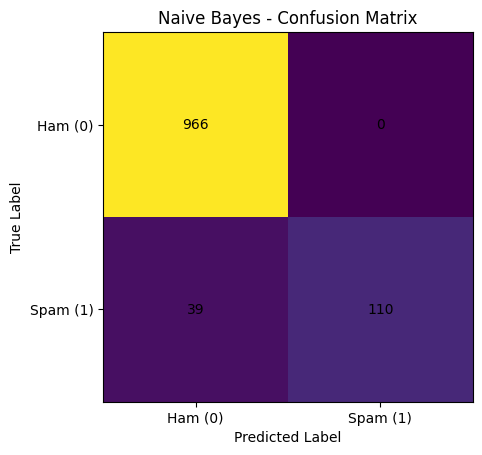

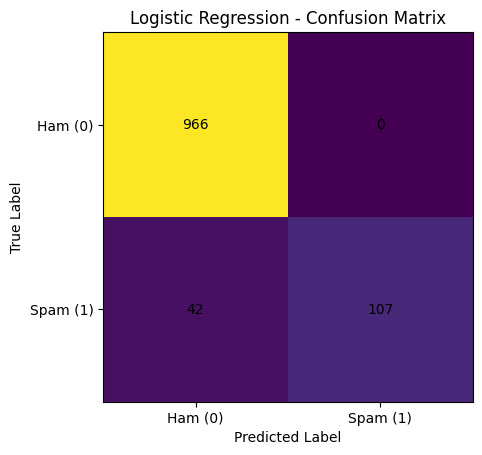

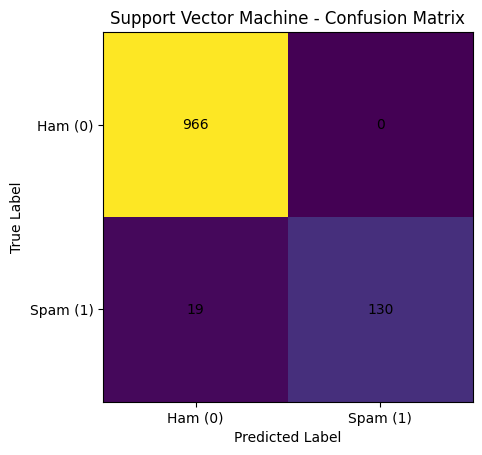

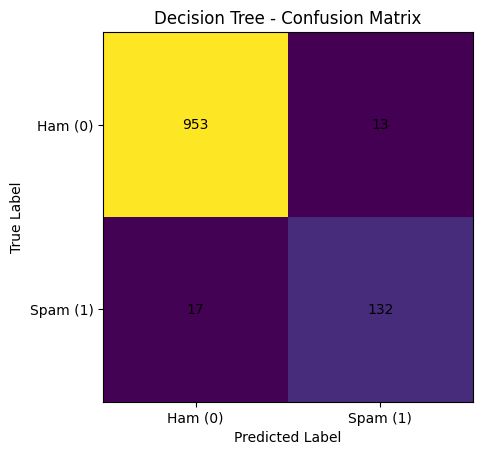

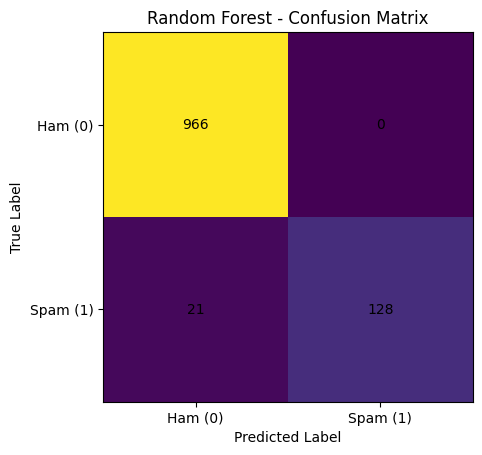

In [62]:
cm = confusion_matrix(y_test, y_pred)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add numbers inside matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
    plt.yticks([0, 1], ['Ham (0)', 'Spam (1)'])

    plt.show()